## 03. PyOMP: `#pragma omp parallel for` from Python

PyOMP brings the **OpenMP programming model** into Python. Inside a
`@numba.openmp.njit` function you write `with openmp("parallel for"):`
and the compiler emits the same kind of parallel-region IR that
`#pragma omp parallel for` produces in C.

This differs from the `@njit(parallel=True)` seen earlier, which is
**Numba's own parallel mode**. PyOMP is OpenMP itself, exposed as a
Python decorator. The directives port to
C / C++ / Fortran without translation.

**SOLUTION**


### Table of Contents

1. [Imports and the OpenMP runtime](#sec1)
2. [The threading probe](#sec2)
3. [The step kernel with `openmp("parallel for")`](#sec3)
4. [Acceptance and timing](#sec4)
5. [Thread scaling](#sec5)
6. [Scaling with data size](#sec6)

### <a id="sec1"></a>1. Imports and the OpenMP runtime

`numba.openmp` exposes both the decorator and the runtime helpers. Set
the thread count once with `omp_set_num_threads(N)` before the first
parallel region.

---

**Quick Docs**

- Use the PyOMP-aware decorator:
  ```python
  from numba.openmp import (
      njit,
      openmp_context as openmp,
      omp_set_num_threads, omp_get_max_threads,
      omp_get_thread_num, omp_get_num_threads,
  )
  ```
- `with openmp("..."):` accepts any OpenMP construct (`parallel for`,
  `reduction(+:x)`, `target teams distribute`, …)
  at JIT time.
- `omp_set_num_threads(N)` sets the thread team size. This is equivalent to
  `OMP_NUM_THREADS=N` in C.


In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import numba

# PyOMP exposes its own njit decorator at numba.openmp.njit
from numba.openmp import njit
from numba.openmp import openmp_context as openmp
from numba.openmp import (
    omp_get_thread_num,
    omp_get_num_threads,
    omp_set_num_threads,
    omp_get_max_threads,
)

import swe_core


# Shared problem parameters
N       = 16384
L       = 10.0
H0      = 1.0
AMP     = 0.1
SIG     = 0.5
CFL     = 0.4
G       = 9.81
N_STEPS = 1000
dx      = L / N
DT      = swe_core.fixed_dt(H0 + AMP, dx, cfl=CFL, g=G)

# Float64 NumPy reference
def run_numpy_reference():
    h, hu = swe_core.bump_ic(N, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    for _ in range(N_STEPS):
        swe_core.apply_bc_reflective(h, hu)
        h, hu = swe_core.step_numpy(h, hu, dx, DT, g=G)
    return h, hu

h_ref, hu_ref = run_numpy_reference()

### <a id="sec2"></a>2. The threading probe

Confirm we got the requested team size by asking the OpenMP runtime
inside a `parallel` region. On an 8-core box with
`omp_set_num_threads(8)` this prints `8`.


In [2]:
omp_set_num_threads(8)

@njit
def probe_threading():
    '''Inside an `openmp("parallel")` region, ask how many threads we got.'''
    n_seen = 0
    with openmp("parallel"):
        if omp_get_thread_num() == 0:
            n_seen = omp_get_num_threads()
    return n_seen

n_observed = probe_threading()
print(f'omp_get_max_threads(): {omp_get_max_threads()}')
print(f'PyOMP threads observed inside parallel: {n_observed}')

omp_get_max_threads(): 8
PyOMP threads observed inside parallel: 8


### <a id="sec3"></a>3. The step kernel with `openmp("parallel for")`

Now, let's implement the same **Read / Compute / Update** shape for our problem, expressed in PyOMP:

- **Read**. Inside a `parallel for`, each thread reads `h[i-1]`, `h[i]`, `h[i+1]` for its slice of cells.
- **Compute**. `rusanov_face(...)` is called twice per cell, for the west and east face.
- **Update**. `h_new[i] = h[i] - (dt/dx) * (Fh_e - Fh_w)`. Each thread writes its own range of `h_new`, so no synchronisation is needed because the iteration space is partitioned.

The per-face flux lives in its own `@njit` helper so the parallel-loop body stays compact. The code shape mirrors what you would write in C-OpenMP.

---

**Quick Docs**

- `with openmp("parallel for"):` parallelises the immediately-following `for` loop. Iterations are distributed across the thread team.
- `with openmp("parallel for reduction(+:total)"):` would parallelise a reduction. We don't use one here. The SWE step writes one output per cell, with no cross-cell accumulation.

In [3]:
DRY_TOL_F = 1e-6

@njit
def rusanov_face(hL, hR, huL, huR, g):
    '''Scalar Rusanov face flux. Pulled into its own @njit function so the
    parallel-loop body stays compact.'''
    hL_s = hL if hL > DRY_TOL_F else DRY_TOL_F
    hR_s = hR if hR > DRY_TOL_F else DRY_TOL_F
    uL = huL / hL_s
    uR = huR / hR_s
    cL = (g * hL_s) ** 0.5
    cR = (g * hR_s) ** 0.5
    a  = max(abs(uL) + cL, abs(uR) + cR)
    Fh  = 0.5 * (huL + huR) - 0.5 * a * (hR - hL)
    Fhu = 0.5 * (huL * uL + 0.5*g*hL*hL +
                 huR * uR + 0.5*g*hR*hR) - 0.5 * a * (huR - huL)
    return Fh, Fhu

@njit
def step_pyomp(h, hu, h_new, hu_new, dx, dt, g):
    '''One Rusanov-flux step. The per-cell loop is wrapped in
    `with openmp("parallel for")`.'''
    Np2 = h.shape[0]
    N   = Np2 - 2
    # Carry ghost cells through (the caller reapplies BCs between steps).
    h_new[0]  = h[0];  hu_new[0]  = hu[0]
    h_new[-1] = h[-1]; hu_new[-1] = hu[-1]
    inv = dt / dx
    with openmp("parallel for"):
        for i in range(1, N + 1):
            Fh_w, Fhu_w = rusanov_face(h[i-1], h[i],   hu[i-1], hu[i],   g)
            Fh_e, Fhu_e = rusanov_face(h[i],   h[i+1], hu[i],   hu[i+1], g)
            h_new[i]  = h[i]  - inv * (Fh_e  - Fh_w)
            hu_new[i] = hu[i] - inv * (Fhu_e - Fhu_w)

### <a id="sec4"></a>4. Acceptance and timing

Two pre-allocated buffers, swapped after each step so the loop allocates nothing. Wall-
clock is measured by `swe_core.timed_run`. Correctness against the
float64 NumPy reference uses `swe_core.max_diff`.

In [4]:
def run_pyomp() -> tuple[np.ndarray, np.ndarray]:
    h, hu = swe_core.bump_ic(N, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    h2 = np.empty_like(h); hu2 = np.empty_like(hu)
    for _ in range(N_STEPS):
        swe_core.apply_bc_reflective(h, hu)
        step_pyomp(h, hu, h2, hu2, dx, DT, G)
        h, hu, h2, hu2 = h2, hu2, h, hu
    return h, hu

# Cold capture (includes Numba + PyOMP compile).
t0 = time.perf_counter()
h_pyomp, _ = run_pyomp()
cold_s = time.perf_counter() - t0
print(f'cold  N={N} x {N_STEPS} steps: {cold_s*1000:7.1f} ms  (incl. JIT + OMP region lowering)')

warm = swe_core.timed_run(run_pyomp, warmup=2, repeats=5, label='03_pyomp')
print(f'warm  N={N} x {N_STEPS} steps: median {warm["median_s"]*1000:7.1f} ms')

diff = swe_core.max_diff(h_ref, h_pyomp)
print(f'max_diff(pyomp_fp64, numpy_fp64) = {diff:.3e}')
TOL = 1e-12
ok = diff < TOL
print(f'{"PASS" if ok else "FAIL"}: within {TOL:.0e} of the NumPy reference.' if ok
      else f'WARN: diff {diff:.2e} exceeds the {TOL:.0e} float64 round-off floor — investigate.')

swe_core.save_timing(
    warm, grid_str=f'N={N}', tool='pyomp', hardware='cpu',
    dtype='float64', steps=N_STEPS,
    cold_s=cold_s, max_diff_vs_numpy=diff,
    threads_observed=int(n_observed),
    numba_version=numba.__version__,
)

cold  N=16384 x 1000 steps:   160.5 ms  (incl. JIT + OMP region lowering)


warm  N=16384 x 1000 steps: median    23.7 ms
max_diff(pyomp_fp64, numpy_fp64) = 0.000e+00
PASS: within 1e-12 of the NumPy reference.


### <a id="sec5"></a>5. Thread scaling

The same kernel scales with `omp_set_num_threads(N)`, with no recompile and
no Python-level orchestration. We re-time the step at 1, 2, 4, 8 threads.

Speedup is near-linear while threads land on idle physical cores, then
flattens. The Rusanov step is **memory-bound**, so once the threads
saturate memory bandwidth or pass the physical-core count, more threads
add little.


  threads = 1:   147.2 ms


  threads = 2:    76.0 ms


  threads = 4:    42.9 ms
  threads = 8:    23.4 ms


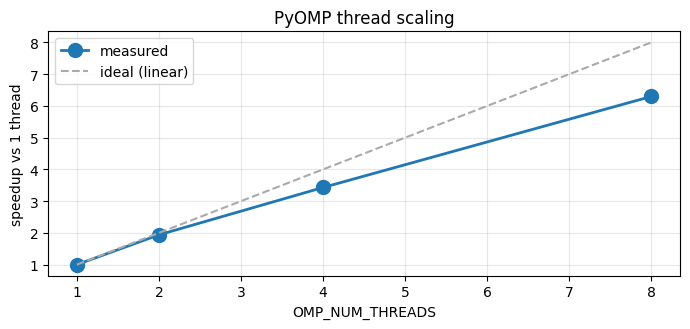

In [5]:
import matplotlib.pyplot as plt

THREAD_COUNTS = [1, 2, 4, 8]
sweep = []
for nthreads in THREAD_COUNTS:
    omp_set_num_threads(nthreads)
    r = swe_core.timed_run(run_pyomp, warmup=2, repeats=3,
                           label=f'pyomp_n{nthreads}')
    sweep.append((nthreads, r['median_s']))
    print(f'  threads = {nthreads}:  {r["median_s"]*1000:6.1f} ms')

ns = [s[0] for s in sweep]
ts = [s[1] for s in sweep]
speedups = [ts[0] / t for t in ts]

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(ns, speedups, 'o-', linewidth=2, markersize=10, label='measured')
ax.plot(ns, ns,       '--', color='#aaa',           label='ideal (linear)')
ax.set_xlabel('OMP_NUM_THREADS'); ax.set_ylabel('speedup vs 1 thread')
ax.set_title('PyOMP thread scaling')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

omp_set_num_threads(8)               # restore default for any later cells

### <a id="sec6"></a>6. Scaling with data size

At a fixed thread count, wall-clock grows ~linearly with `N`: the step is
O(N) in arithmetic and memory traffic. We measure warm timings at
`N = 16384, 65536, 262144` below. Quadrupling `N` roughly quadruples the time,
and throughput flattens at the memory-bandwidth ceiling (the same limit that
caps thread scaling in section 5).

Unlike JAX, a new `N` triggers no recompile here. Numba specialises on
`dtype` and rank, not shape, so there is no cold spike to chart.

  N=16384:  warm   23.8 ms    687.2 M cell-updates/s


  N=65536:  warm   80.0 ms    818.7 M cell-updates/s


  N=262144:  warm  317.3 ms    826.2 M cell-updates/s


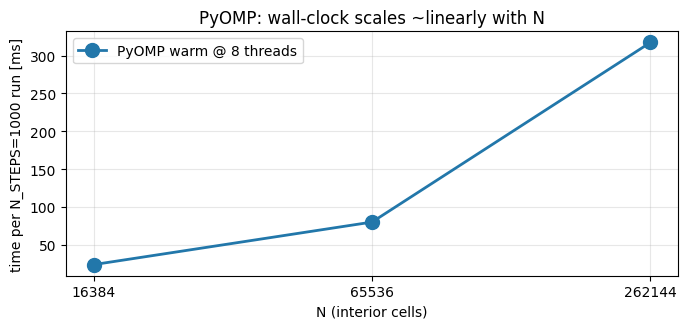

In [6]:
grid_data = []
for N_local in [16384, 65536, 262144]:
    L_local  = 10.0
    dx_local = L_local / N_local
    DT_local = swe_core.fixed_dt(H0 + AMP, dx_local, cfl=CFL, g=G)

    def run_at(N_=N_local, dx_=dx_local, dt_=DT_local):
        h, hu = swe_core.bump_ic(N_, L=L_local, h0=H0, amplitude=AMP, sigma=SIG)
        h2, hu2 = np.empty_like(h), np.empty_like(hu)
        for _ in range(N_STEPS):
            swe_core.apply_bc_reflective(h, hu)
            step_pyomp(h, hu, h2, hu2, dx_, dt_, G)
            h, hu, h2, hu2 = h2, hu2, h, hu
        return h, hu

    r = swe_core.timed_run(run_at, warmup=2, repeats=5,
                            label=f'pyomp_N{N_local}')
    cells_per_s = N_local * N_STEPS / r['median_s']
    grid_data.append((N_local, r['median_s'], cells_per_s))
    print(f'  N={N_local:>5}:  warm {r["median_s"]*1000:6.1f} ms   '
          f'{cells_per_s/1e6:6.1f} M cell-updates/s')

Ns      = [d[0] for d in grid_data]
warm_ms = [d[1]*1000 for d in grid_data]

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(Ns, warm_ms, 'o-', linewidth=2, markersize=10, color='#27a',
        label='PyOMP warm @ 8 threads')
ax.set_xlabel('N (interior cells)')
ax.set_ylabel('time per N_STEPS=1000 run [ms]')
ax.set_title('PyOMP: wall-clock scales ~linearly with N')
ax.set_xscale('log', base=2); ax.set_xticks(Ns); ax.set_xticklabels([str(n) for n in Ns])
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


**Recap.**

- Same `#pragma omp parallel for` directives as C, exposed via a
  Python context manager.
- Thread scaling works (section 5), and the kernel handles any `N`
  with no recompile (section 6).

Next: `04__nanobind__.ipynb` drops into C++. We compile a
hand-written kernel and call it from Python through a binding library.
